In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv.csv to dataset.csv.csv


In [ ]:
import os
print(os.listdir())

['.config', 'dataset.csv.csv', 'sample_data']


In [ ]:
import pandas as pd
df=pd.read_csv("dataset.csv.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
df['Has Online delivery'].value_counts()

,count
Has Online delivery,
No,7100
Yes,2451


In [ ]:
delivery_pct = df['Has Online delivery'].value_counts(normalize=True) * 100
print(delivery_pct.round(2))

Has Online delivery
No     74.34
Yes    25.66
Name: proportion, dtype: float64


In [ ]:
avg_rating_by_delivery = df.groupby('Has Online delivery')['Aggregate rating'].mean()
print(avg_rating_by_delivery.round(2))

Has Online delivery
No     2.47
Yes    3.25
Name: Aggregate rating, dtype: float64


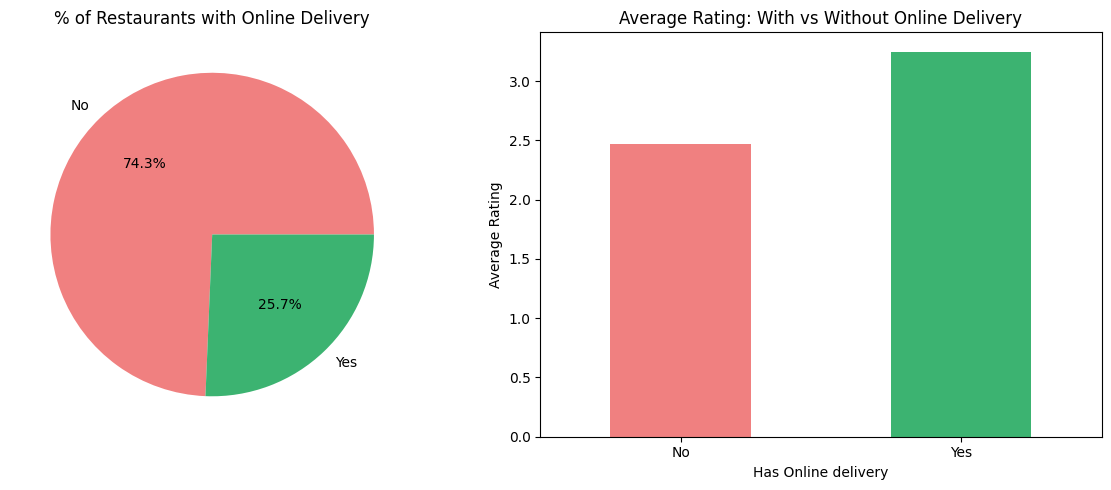

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Pie chart - % of restaurants with online delivery
delivery_pct.plot(kind='pie', autopct='%1.1f%%', ax=axes[0], colors=['lightcoral','mediumseagreen'])
axes[0].set_title('% of Restaurants with Online Delivery')
axes[0].set_ylabel('')

# Bar chart - avg rating comparison
avg_rating_by_delivery.plot(kind='bar', ax=axes[1], color=['lightcoral','mediumseagreen'])
axes[1].set_title('Average Rating: With vs Without Online Delivery')
axes[1].set_ylabel('Average Rating')
axes[1].set_xticklabels(avg_rating_by_delivery.index, rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
summary = pd.DataFrame({
    'Percentage': delivery_pct.round(2),
    'Avg Rating': avg_rating_by_delivery.round(2)
})
print(summary)

                     Percentage  Avg Rating
Has Online delivery                        
No                        74.34        2.47
Yes                       25.66        3.25


Only about a quarter of restaurants (25.66%) offer online delivery. However, those that do have a noticeably higher average rating (3.25) compared to those that don't (2.47) — suggesting restaurants offering online delivery tend to be better-rated, though this is a correlation, not necessarily a cause-and-effect relationship.